# Electrical Bus Energy Consumption — Data Preprocessing

**Data Science Take-Home Assignment**

This notebook processes raw data logger and weather data from 24 electrical bus trips to produce a clean, feature-rich training dataset that can be used to train a machine learning model predicting energy consumption per trip.

## Outline
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning (missing values, error codes)
4. Signal Processing (noisy weight signal)
5. Energy Consumption Calculation
6. Weather Data Integration
7. Feature Engineering
8. Final Training Dataset
9. Summary Statistics & Feature Correlations


In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
from scipy.signal import medfilt
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR  = os.path.join('data')
TRIPS_DIR = os.path.join(DATA_DIR, 'trips')
WEATHER_FILE = os.path.join(DATA_DIR, 'weather.csv')
OUTPUT_FILE  = os.path.join(DATA_DIR, 'training_dataset.csv')

print("Data directory:", DATA_DIR)
print("Trip files found:", len(glob.glob(os.path.join(TRIPS_DIR, '*.csv'))))


Data directory: data
Trip files found: 24


## 1. Load Trip Data

Load all 24 trip CSV files. Each file represents a single trip recorded at 1 Hz. We add a `trip_id` column to keep track of individual trips once all files are concatenated.


In [2]:
def load_trip(filepath):
    trip_id = os.path.splitext(os.path.basename(filepath))[0]
    df = pd.read_csv(filepath, dtype=str)
    df.insert(0, 'trip_id', trip_id)
    return df

trip_files = sorted(glob.glob(os.path.join(TRIPS_DIR, '*.csv')))
raw_trips = pd.concat([load_trip(f) for f in trip_files], ignore_index=True)

print(f"Total rows loaded : {len(raw_trips):,}")
print(f"Total trips       : {raw_trips['trip_id'].nunique()}")
print()
print("Columns:", list(raw_trips.columns))
print()
raw_trips.head(3)


Total rows loaded : 70,740
Total trips       : 24

Columns: ['trip_id', 'time', 'charge', 'power', 'odometer', 'weight', 'temperature', 'doors', 'start_date', 'start_time']



,trip_id,time,charge,power,odometer,weight,temperature,doors,start_date,start_time
0,trip_01,0,0,-59.64046743049665,65601.86456774823,16114.582494377124,4.78,2,2023-02-12,17:20:00
1,trip_01,1,0,-57.377245082750854,65601.86466222157,16200.981638688902,4.77,2,2023-02-12,17:20:00
2,trip_01,2,NaN,-59.302984816204386,65601.86515487303,16155.793832168787,5.56,2,2023-02-12,17:20:00


## 2. Exploratory Data Analysis


In [3]:
trip_summary = raw_trips.groupby('trip_id').agg(
    n_rows=('time', 'count'),
    start_date=('start_date', 'first'),
    start_time=('start_time', 'first'),
).reset_index()
print("Per-trip row counts:")
print(trip_summary.to_string(index=False))


Per-trip row counts:


trip_id  n_rows start_date start_time
trip_01    2100 2023-02-12   17:20:00
trip_02    3300 2023-01-24   13:10:00
trip_03    2520 2023-01-22   16:36:00
trip_04    1680 2023-01-23   18:25:00
trip_05    4200 2023-01-30   18:11:00
trip_06    2880 2023-02-01   13:29:00
trip_07    2280 2023-04-15   12:05:00
trip_08    3600 2023-04-17   16:52:00
trip_09    1920 2023-04-25   13:50:00
trip_10    4500 2023-04-29   17:52:00
trip_11    2640 2023-04-28   13:39:00
trip_12    3120 2023-04-27   13:38:00
trip_13    2400 2023-07-17   17:17:00
trip_14    3480 2023-08-09   07:41:00
trip_15    2100 2023-07-26   12:04:00
trip_16    3900 2023-08-03   12:37:00
trip_17    2700 2023-08-05   17:06:00
trip_18    3000 2023-07-19   08:33:00
trip_19    2220 2023-10-25   14:41:00
trip_20    3720 2023-10-27   12:45:00
trip_21    1740 2023-10-27   16:29:00
trip_22    4800 2023-10-31   13:55:00
trip_23    2580 2023-10-27   09:40:00
trip_24    3360 2023-10-09   08:52:00


In [4]:
for col in ['charge', 'doors']:
    unique_vals = raw_trips[col].unique()
    print(f"Unique values in '{col}': {unique_vals}")


Unique values in 'charge': <StringArray>
['0', nan, 'error']
Length: 3, dtype: str
Unique values in 'doors': <StringArray>
['2', 'error', '0', '1']
Length: 4, dtype: str


In [5]:
missing = raw_trips.isnull().sum()
missing_pct = (missing / len(raw_trips) * 100).round(2)
print("Missing value counts (%):")
print(pd.DataFrame({'count': missing, 'percent': missing_pct}).to_string())


Missing value counts (%):
             count  percent
trip_id          0     0.00
time             0     0.00
charge        1408     1.99
power          701     0.99
odometer         0     0.00
weight         344     0.49
temperature      0     0.00
doors            0     0.00
start_date       0     0.00
start_time       0     0.00


## 3. Data Cleaning

### 3.1 Type Conversion

Convert all numeric columns from string to appropriate dtypes.
Non-numeric placeholders (`'error'`, `'nan'`, etc.) are replaced with `NaN`.


In [6]:
numeric_cols = ['time', 'charge', 'power', 'odometer', 'weight', 'temperature', 'doors']

trips = raw_trips.copy()
for col in numeric_cols:
    trips[col] = pd.to_numeric(trips[col], errors='coerce')

trips['time'] = trips['time'].astype('Int64')

trips['start_datetime'] = pd.to_datetime(
    trips['start_date'] + ' ' + trips['start_time'],
    format='%Y-%m-%d %H:%M:%S', errors='coerce'
)

print("Data types after conversion:")
print(trips.dtypes)
print()
trips.head(3)


Data types after conversion:
trip_id                      str
time                       Int64
charge                   float64
power                    float64
odometer                 float64
weight                   float64
temperature              float64
doors                    float64
start_date                   str
start_time                   str
start_datetime    datetime64[us]
dtype: object



,trip_id,time,charge,power,odometer,weight,temperature,doors,start_date,start_time,start_datetime
0,trip_01,0,0.0,-59.640467,65601.864568,16114.582494,4.78,2.0,2023-02-12,17:20:00,2023-02-12 17:20:00
1,trip_01,1,0.0,-57.377245,65601.864662,16200.981639,4.77,2.0,2023-02-12,17:20:00,2023-02-12 17:20:00
2,trip_01,2,NaN,-59.302985,65601.865155,16155.793832,5.56,2.0,2023-02-12,17:20:00,2023-02-12 17:20:00


### 3.2 Validate and Clean `charge` Column

`charge` should be 0 (discharging) or 1 (charging).
Any `'error'` entry has been coerced to `NaN`.
We forward-fill within each trip and default remaining NaN to 0 (discharging).


In [7]:
before = trips['charge'].isnull().sum()

trips['charge'] = (
    trips.groupby('trip_id')['charge']
    .transform(lambda s: s.ffill().bfill())
)
trips['charge'] = trips['charge'].fillna(0).clip(0, 1).round().astype(int)

after = trips['charge'].isnull().sum()
print(f"'charge' NaN before fill: {before}  |  after fill: {after}")
print("Value counts:")
print(trips['charge'].value_counts())


'charge' NaN before fill: 1743  |  after fill: 0
Value counts:
charge
0    70740
Name: count, dtype: int64


### 3.3 Validate and Clean `doors` Column

`doors` should be 0, 1, or 2. Errors/missing values are forward-filled, then defaulted to 2 (all closed).


In [8]:
before = trips['doors'].isnull().sum()

trips['doors'] = (
    trips.groupby('trip_id')['doors']
    .transform(lambda s: s.ffill().bfill())
)
trips['doors'] = trips['doors'].fillna(2).clip(0, 2).round().astype(int)

after = trips['doors'].isnull().sum()
print(f"'doors' NaN before fill: {before}  |  after fill: {after}")
print("Value counts:")
print(trips['doors'].value_counts())


'doors' NaN before fill: 201  |  after fill: 0
Value counts:
doors
2    68348
0     2194
1      198
Name: count, dtype: int64


### 3.4 Interpolate Missing Numeric Signals

For `power`, `odometer`, and `temperature` we use linear interpolation within each trip
to fill short gaps (≤ 30 s). Longer gaps remain `NaN` and will be excluded from energy integration.


In [9]:
MAX_INTERP_GAP = 30  # seconds

for col in ['power', 'odometer', 'temperature']:
    before = trips[col].isnull().sum()
    trips[col] = trips.groupby('trip_id')[col].transform(
        lambda s: s.interpolate(method='linear', limit=MAX_INTERP_GAP, limit_direction='both')
    )
    after = trips[col].isnull().sum()
    print(f"'{col}' NaN:  {before} -> {after} (after interpolation, limit={MAX_INTERP_GAP}s)")


'power' NaN:  701 -> 0 (after interpolation, limit=30s)
'odometer' NaN:  0 -> 0 (after interpolation, limit=30s)
'temperature' NaN:  0 -> 0 (after interpolation, limit=30s)


## 4. Weight Signal Processing

The `weight` signal is heavily contaminated by vehicle movement. Strategy:

1. **Median filter** (kernel = 31 s) to remove high-frequency noise.
2. Keep only values recorded **when the bus is stationary** (speed ≈ 0).
3. **Rolling-window median** of stationary readings to produce a smooth weight estimate.
4. Fill any remaining gaps via forward/backward-fill.


In [10]:
# Compute per-trip speed (km/h) from odometer differences
trips = trips.sort_values(['trip_id', 'time']).reset_index(drop=True)

trips['speed_kmh'] = (
    trips.groupby('trip_id')['odometer']
    .transform(lambda x: x.diff().fillna(0))
    * 3600       # Δkm/s -> km/h
).clip(lower=0)

trips['is_stationary'] = trips['speed_kmh'] < 2.0

print(f"Stationary samples: {trips['is_stationary'].sum():,} / {len(trips):,}")


Stationary samples: 3,868 / 70,740


In [11]:
def clean_weight_for_trip(w_vals, stationary_vals):
    """Apply median filter + stationary rolling median to a weight array."""
    w = w_vals.astype(float)
    # Fill NaN before filtering
    w_filled = pd.Series(w).ffill().bfill().values
    if np.isnan(w_filled).all():
        return np.full(len(w), np.nan)
    # Step 1: median filter
    w_med = medfilt(w_filled, kernel_size=31)
    # Step 2: keep only stationary readings
    w_stat = np.where(stationary_vals, w_med, np.nan)
    # Step 3: rolling median over stationary readings
    w_smooth = pd.Series(w_stat).rolling(window=120, min_periods=1, center=True).median()
    # Fill forward/backward
    return w_smooth.ffill().bfill().values


weight_clean_parts = []
for trip_id, group in trips.groupby('trip_id'):
    wc = clean_weight_for_trip(group['weight'].values, group['is_stationary'].values)
    weight_clean_parts.append(pd.Series(wc, index=group.index))

trips['weight_clean'] = pd.concat(weight_clean_parts)

print("Weight cleaning done.")
print(f"  Raw weight NaN  : {trips['weight'].isnull().sum()}")
print(f"  Clean weight NaN: {trips['weight_clean'].isnull().sum()}")


Weight cleaning done.
  Raw weight NaN  : 344
  Clean weight NaN: 0


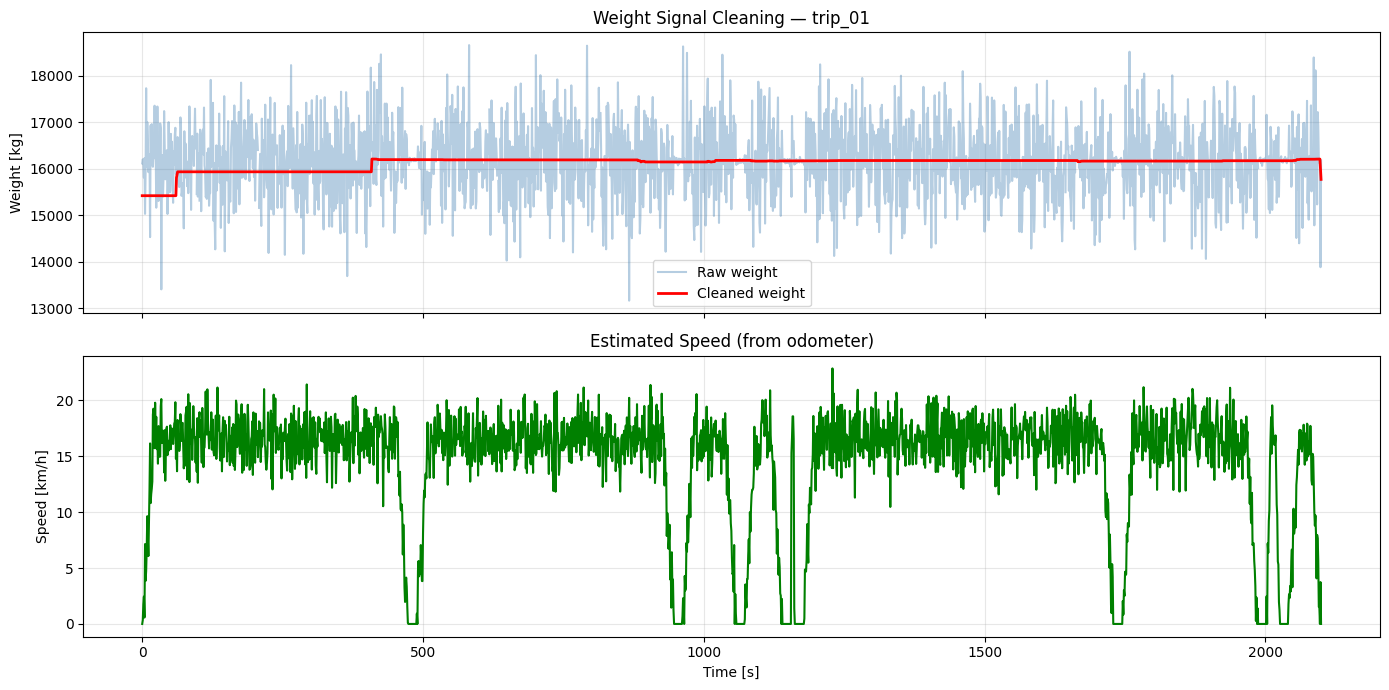

Plot saved to data/weight_cleaning.png


In [12]:
# Visualise weight cleaning for one trip
sample_trip = 'trip_01'
sdf = trips[trips['trip_id'] == sample_trip].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(sdf['time'], sdf['weight'], alpha=0.4, label='Raw weight', color='steelblue')
axes[0].plot(sdf['time'], sdf['weight_clean'], color='red', lw=2, label='Cleaned weight')
axes[0].set_ylabel('Weight [kg]')
axes[0].set_title(f'Weight Signal Cleaning — {sample_trip}')
axes[0].legend()

axes[1].plot(sdf['time'], sdf['speed_kmh'], color='green')
axes[1].set_ylabel('Speed [km/h]')
axes[1].set_xlabel('Time [s]')
axes[1].set_title('Estimated Speed (from odometer)')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'weight_cleaning.png'), dpi=100)
plt.show()
print("Plot saved to data/weight_cleaning.png")


## 5. Energy Consumption Calculation

Total energy consumed per trip is obtained by **numerically integrating the discharge power** over time:

$$E_{\text{trip}} = \int_{t_0}^{t_N} P_{\text{discharge}}(t)\, dt$$

Since the data is sampled at 1 Hz, each sample represents 1 second:

$$E_{\text{trip}} [\text{kWh}] = \frac{1}{3600} \sum_{i:\, \text{charge}_i = 0,\, P_i \neq \text{NaN}} |P_i|$$

We only sum samples where `charge == 0` (battery discharging) and `power` is not NaN.


In [13]:
trips['is_discharge'] = (trips['charge'] == 0) & trips['power'].notna()

# Energy per second [kWh]
trips['energy_per_sec_kwh'] = np.where(
    trips['is_discharge'],
    trips['power'].abs() / 3600.0,
    0.0
)

energy_per_trip = (
    trips.groupby('trip_id')['energy_per_sec_kwh']
    .sum()
    .rename('total_energy_kwh')
    .reset_index()
)
print("Energy consumption per trip [kWh]:")
print(energy_per_trip.to_string(index=False))


Energy consumption per trip [kWh]:
trip_id  total_energy_kwh
trip_01         52.983694
trip_02        118.918794
trip_03         78.697014
trip_04         45.674201
trip_05        174.829300
trip_06         69.157325
trip_07         53.648265
trip_08        114.795684
trip_09         53.021878
trip_10        118.594435
trip_11         71.806788
trip_12        120.139716
trip_13         68.397411
trip_14        121.886800
trip_15         64.382750
trip_16        165.099945
trip_17         74.332609
trip_18        145.463643
trip_19         59.713375
trip_20        139.816353
trip_21         42.956222
trip_22        126.636019
trip_23         67.154138
trip_24        136.455033


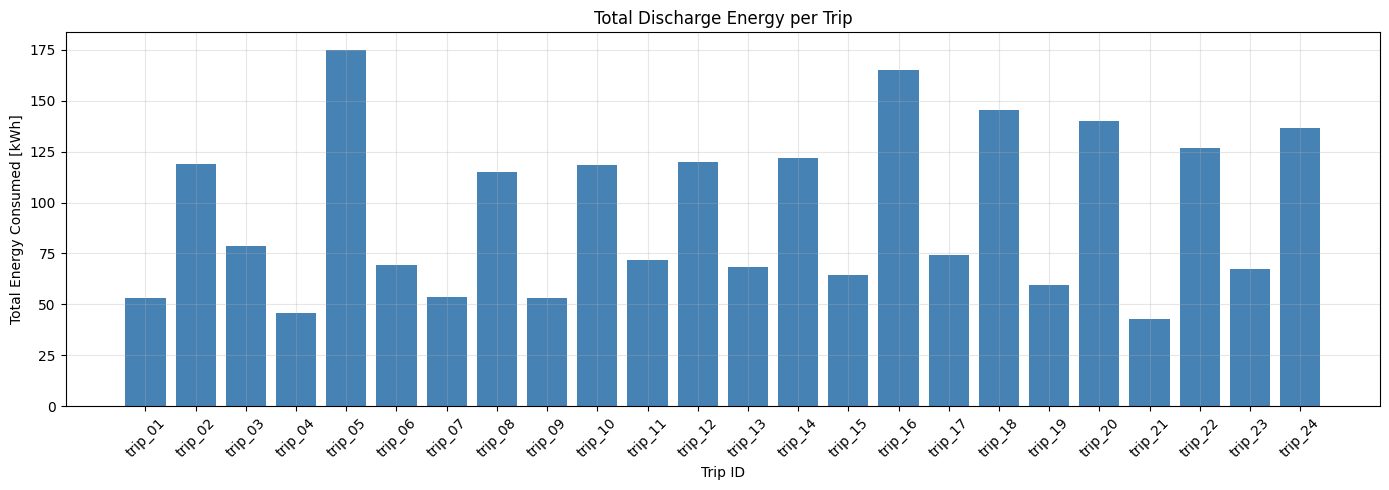

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(energy_per_trip['trip_id'], energy_per_trip['total_energy_kwh'], color='steelblue')
ax.set_xlabel('Trip ID')
ax.set_ylabel('Total Energy Consumed [kWh]')
ax.set_title('Total Discharge Energy per Trip')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'energy_per_trip.png'), dpi=100)
plt.show()


## 6. Weather Data Integration


In [15]:
weather = pd.read_csv(WEATHER_FILE)
weather['datetime'] = pd.to_datetime(weather['datetime'])

print(f"Weather rows: {len(weather):,}  |  date range: {weather['datetime'].min()} -> {weather['datetime'].max()}")
weather.head(3)


Weather rows: 8,016  |  date range: 2023-01-01 00:00:00 -> 2023-11-30 23:00:00


,datetime,date,hour,outdoor_temperature,humidity,wind_speed,precipitation,cloud_cover
0,2023-01-01 00:00:00,2023-01-01,0,-10.5,77.6,1.5,0.0,78.8
1,2023-01-01 01:00:00,2023-01-01,1,-6.5,70.1,2.3,0.0,57.9
2,2023-01-01 02:00:00,2023-01-01,2,-7.7,25.8,3.2,0.0,51.8


In [16]:
# Per-trip start metadata (one row per trip)
trip_meta = trips.groupby('trip_id').agg(
    start_datetime=('start_datetime', 'first'),
    start_date=('start_date', 'first'),
    start_time=('start_time', 'first'),
).reset_index()

trip_meta['start_datetime'] = pd.to_datetime(trip_meta['start_datetime'])
trip_meta['weather_hour']   = trip_meta['start_datetime'].dt.round('h')

weather_hourly = weather[['datetime', 'outdoor_temperature', 'humidity',
                           'wind_speed', 'precipitation', 'cloud_cover']].copy()
weather_hourly = weather_hourly.rename(columns={'datetime': 'weather_hour'})

trip_meta = trip_meta.merge(weather_hourly, on='weather_hour', how='left')

print(f"Trip metadata with weather: {len(trip_meta)} rows")
trip_meta[['trip_id', 'start_datetime', 'outdoor_temperature', 'humidity', 'wind_speed']].head()


Trip metadata with weather: 24 rows


,trip_id,start_datetime,outdoor_temperature,humidity,wind_speed
0,trip_01,2023-02-12 17:20:00,-0.7,61.9,4.3
1,trip_02,2023-01-24 13:10:00,-0.2,47.0,0.7
2,trip_03,2023-01-22 16:36:00,-4.8,86.3,4.5
3,trip_04,2023-01-23 18:25:00,-3.2,63.1,1.5
4,trip_05,2023-01-30 18:11:00,1.8,30.4,0.0


## 7. Feature Engineering

Per-trip features that characterise the route and operating conditions.

| Feature | Description |
|---|---|
| `trip_duration_s` | Total trip duration in seconds |
| `trip_distance_km` | Total distance covered |
| `avg_speed_kmh` | Average speed [km/h] |
| `max_speed_kmh` | Maximum speed [km/h] |
| `speed_std_kmh` | Standard deviation of speed (route variability) |
| `n_stops` | Number of distinct stops |
| `total_stop_time_s` | Total seconds stationary |
| `stop_time_fraction` | Fraction of trip time stationary |
| `door_open_time_s` | Total seconds any door is open |
| `door_open_fraction` | Fraction of trip time with doors open |
| `n_door_events` | Number of distinct door-open events |
| `avg_indoor_temp` | Average interior temperature [°C] |
| `avg_weight_kg` | Average cleaned bus weight [kg] |
| `outdoor_temperature` | Outdoor temperature at trip start [°C] |
| `humidity` | Relative humidity at trip start [%] |
| `wind_speed` | Wind speed at trip start [m/s] |
| `precipitation` | Precipitation at trip start [mm/h] |
| `month` | Month (seasonal proxy) |
| `hour_of_day` | Hour of the day (demand proxy) |
| `is_weekend` | 1 if weekend, 0 if weekday |


In [17]:
def count_events(arr, min_duration=5):
    """Count distinct events where condition is True for >= min_duration consecutive samples."""
    in_event, event_count, run_len = False, 0, 0
    for val in arr:
        if val:
            run_len += 1
            in_event = True
        else:
            if in_event and run_len >= min_duration:
                event_count += 1
            in_event, run_len = False, 0
    if in_event and run_len >= min_duration:
        event_count += 1
    return event_count


def extract_features(group):
    """Extract per-trip features from a single trip's time-series data."""
    features = {}

    features['trip_duration_s']    = int(group['time'].max() - group['time'].min()) + 1
    features['trip_distance_km']   = round(group['odometer'].max() - group['odometer'].min(), 3)

    speed = group['speed_kmh'].dropna()
    features['avg_speed_kmh']  = round(speed.mean(), 2)
    features['max_speed_kmh']  = round(speed.max(), 2)
    features['speed_std_kmh']  = round(speed.std(), 2)

    stationary = group['is_stationary'].values
    features['total_stop_time_s']  = int(stationary.sum())
    features['stop_time_fraction'] = round(stationary.mean(), 4)
    features['n_stops']            = count_events(stationary, min_duration=5)

    door_open = (group['doors'] == 0).values
    features['door_open_time_s']   = int(door_open.sum())
    features['door_open_fraction'] = round(door_open.mean(), 4)
    features['n_door_events']      = count_events(door_open, min_duration=2)

    features['avg_indoor_temp'] = round(group['temperature'].mean(), 2)
    features['avg_weight_kg']   = round(group['weight_clean'].mean(), 1)

    return pd.Series(features)


print("Extracting trip-level features...")
feature_rows = []
for trip_id, group in trips.groupby('trip_id'):
    feats = extract_features(group)
    feats['trip_id'] = trip_id
    feature_rows.append(feats)

trip_features = pd.DataFrame(feature_rows).reset_index(drop=True)
print(f"Feature matrix shape: {trip_features.shape}")
trip_features.head()


Extracting trip-level features...
Feature matrix shape: (24, 14)


,trip_duration_s,trip_distance_km,avg_speed_kmh,max_speed_kmh,speed_std_kmh,total_stop_time_s,stop_time_fraction,n_stops,door_open_time_s,door_open_fraction,n_door_events,avg_indoor_temp,avg_weight_kg,trip_id
0,2100.0,8.457,14.50,22.85,5.21,160.0,0.0762,8.0,88.0,0.0419,8.0,20.66,16113.0,trip_01
1,3300.0,28.137,30.70,40.04,7.69,114.0,0.0345,6.0,66.0,0.0200,6.0,20.86,12801.3,trip_02
2,2520.0,10.596,15.14,23.47,5.48,202.0,0.0802,9.0,103.0,0.0409,9.0,20.74,17218.2,trip_03
3,1680.0,8.496,18.21,26.30,6.86,138.0,0.0821,6.0,77.0,0.0458,7.0,20.15,17254.1,trip_04
4,4200.0,46.212,39.61,48.77,9.77,145.0,0.0345,8.0,88.0,0.0210,8.0,21.07,14202.9,trip_05


In [18]:
# Merge weather and datetime features
trip_features = trip_features.merge(trip_meta, on='trip_id', how='left')

trip_features['month']       = trip_features['start_datetime'].dt.month
trip_features['hour_of_day'] = trip_features['start_datetime'].dt.hour
trip_features['is_weekend']  = trip_features['start_datetime'].dt.dayofweek.ge(5).astype(int)

# Merge energy target
trip_features = trip_features.merge(energy_per_trip, on='trip_id', how='left')

print(f"Final feature matrix shape: {trip_features.shape}")
trip_features.dtypes


Final feature matrix shape: (24, 27)


trip_duration_s               float64
trip_distance_km              float64
avg_speed_kmh                 float64
max_speed_kmh                 float64
speed_std_kmh                 float64
total_stop_time_s             float64
stop_time_fraction            float64
n_stops                       float64
door_open_time_s              float64
door_open_fraction            float64
n_door_events                 float64
avg_indoor_temp               float64
avg_weight_kg                 float64
trip_id                           str
start_datetime         datetime64[us]
start_date                        str
start_time                        str
weather_hour           datetime64[us]
outdoor_temperature           float64
humidity                      float64
wind_speed                    float64
precipitation                 float64
cloud_cover                   float64
month                           int32
hour_of_day                     int32
is_weekend                      int64
total_energy

## 8. Final Training Dataset


In [19]:
FEATURE_COLS = [
    'trip_id',
    'trip_duration_s', 'trip_distance_km',
    'avg_speed_kmh', 'max_speed_kmh', 'speed_std_kmh',
    'n_stops', 'total_stop_time_s', 'stop_time_fraction',
    'n_door_events', 'door_open_time_s', 'door_open_fraction',
    'avg_indoor_temp', 'avg_weight_kg',
    'outdoor_temperature', 'humidity', 'wind_speed', 'precipitation',
    'month', 'hour_of_day', 'is_weekend',
    'total_energy_kwh',
]

training_df = trip_features[FEATURE_COLS].copy()

print(f"Training dataset shape : {training_df.shape}")
print(f"Missing values per column:")
print(training_df.isnull().sum())
print()
training_df


Training dataset shape : (24, 22)
Missing values per column:
trip_id                0
trip_duration_s        0
trip_distance_km       0
avg_speed_kmh          0
max_speed_kmh          0
speed_std_kmh          0
n_stops                0
total_stop_time_s      0
stop_time_fraction     0
n_door_events          0
door_open_time_s       0
door_open_fraction     0
avg_indoor_temp        0
avg_weight_kg          0
outdoor_temperature    0
humidity               0
wind_speed             0
precipitation          0
month                  0
hour_of_day            0
is_weekend             0
total_energy_kwh       0
dtype: int64



,trip_id,trip_duration_s,trip_distance_km,avg_speed_kmh,max_speed_kmh,speed_std_kmh,n_stops,total_stop_time_s,stop_time_fraction,n_door_events,...,avg_indoor_temp,avg_weight_kg,outdoor_temperature,humidity,wind_speed,precipitation,month,hour_of_day,is_weekend,total_energy_kwh
0,trip_01,2100.0,8.457,14.50,22.85,5.21,8.0,160.0,0.0762,8.0,...,20.66,16113.0,-0.7,61.9,4.3,0.0,2,17,1,52.983694
1,trip_02,3300.0,28.137,30.70,40.04,7.69,6.0,114.0,0.0345,6.0,...,20.86,12801.3,-0.2,47.0,0.7,0.0,1,13,0,118.918794
2,trip_03,2520.0,10.596,15.14,23.47,5.48,9.0,202.0,0.0802,9.0,...,20.74,17218.2,-4.8,86.3,4.5,0.0,1,16,1,78.697014
3,trip_04,1680.0,8.496,18.21,26.30,6.86,6.0,138.0,0.0821,7.0,...,20.15,17254.1,-3.2,63.1,1.5,0.0,1,18,0,45.674201
4,trip_05,4200.0,46.212,39.61,48.77,9.77,8.0,145.0,0.0345,8.0,...,21.07,14202.9,1.8,30.4,0.0,0.0,1,18,0,174.829300
5,trip_06,2880.0,13.507,16.88,25.36,6.39,12.0,232.0,0.0806,12.0,...,20.48,14909.6,-0.8,84.4,1.4,0.0,2,13,0,69.157325
6,trip_07,2280.0,10.460,16.52,25.12,6.17,9.0,182.0,0.0798,9.0,...,21.64,15345.1,23.9,72.8,0.5,0.0,4,12,1,53.648265
7,trip_08,3600.0,31.700,31.70,40.67,7.42,5.0,111.0,0.0308,6.0,...,21.75,13175.9,22.6,74.1,3.8,0.0,4,16,0,114.795684
8,trip_09,1920.0,10.291,19.30,27.97,7.39,8.0,160.0,0.0833,8.0,...,21.32,15650.0,26.3,58.7,1.5,0.0,4,13,0,53.021878
9,trip_10,4500.0,33.333,26.67,35.03,6.91,9.0,174.0,0.0387,9.0,...,21.62,13852.3,24.7,83.1,4.3,0.0,4,17,1,118.594435


In [20]:
training_df.to_csv(OUTPUT_FILE, index=False)
print(f"Training dataset saved to: {OUTPUT_FILE}")


Training dataset saved to: data/training_dataset.csv


## 9. Summary Statistics & Feature Correlations


In [21]:
training_df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
trip_duration_s,24.0,2947.50,866.29,1680.00,2265.00,2790.00,3510.00,4800.00
trip_distance_km,24.0,21.75,12.96,6.96,10.42,13.98,33.46,46.21
avg_speed_kmh,24.0,24.70,9.70,14.40,16.48,19.74,32.46,41.09
max_speed_kmh,24.0,33.54,9.94,22.77,25.37,28.46,41.41,50.42
speed_std_kmh,24.0,7.34,1.62,5.21,6.24,6.88,7.86,10.46
n_stops,24.0,8.17,1.83,5.00,6.75,8.00,9.00,12.00
total_stop_time_s,24.0,161.17,36.97,109.00,130.75,160.00,183.75,232.00
stop_time_fraction,24.0,0.06,0.02,0.03,0.04,0.07,0.08,0.09
n_door_events,24.0,8.25,1.70,6.00,7.00,8.00,9.00,12.00
door_open_time_s,24.0,91.42,18.43,66.00,77.00,88.00,102.25,132.00


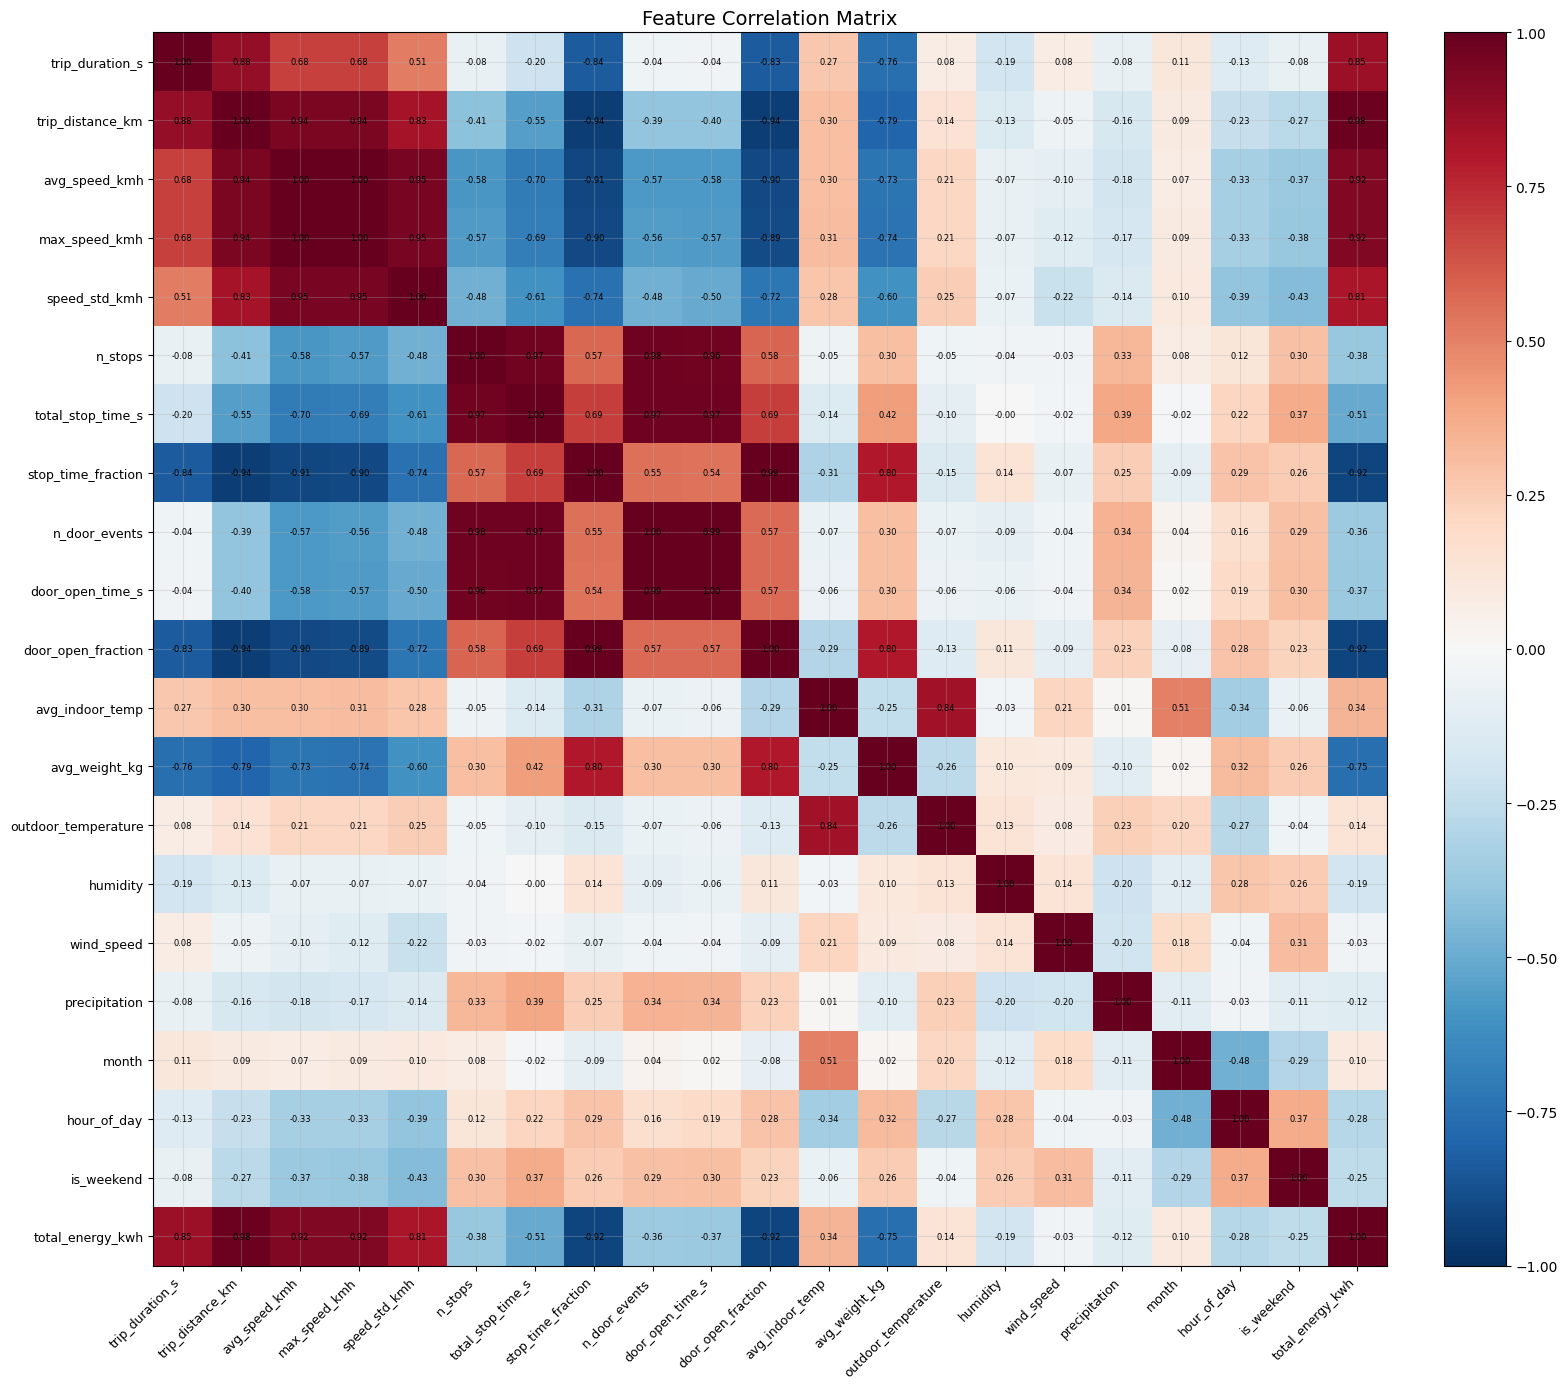

In [22]:
numeric_features = [c for c in FEATURE_COLS if c != 'trip_id']
corr = training_df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(numeric_features)))
ax.set_yticks(range(len(numeric_features)))
ax.set_xticklabels(numeric_features, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(numeric_features, fontsize=9)
ax.set_title('Feature Correlation Matrix', fontsize=14)
for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'correlation_heatmap.png'), dpi=100)
plt.show()


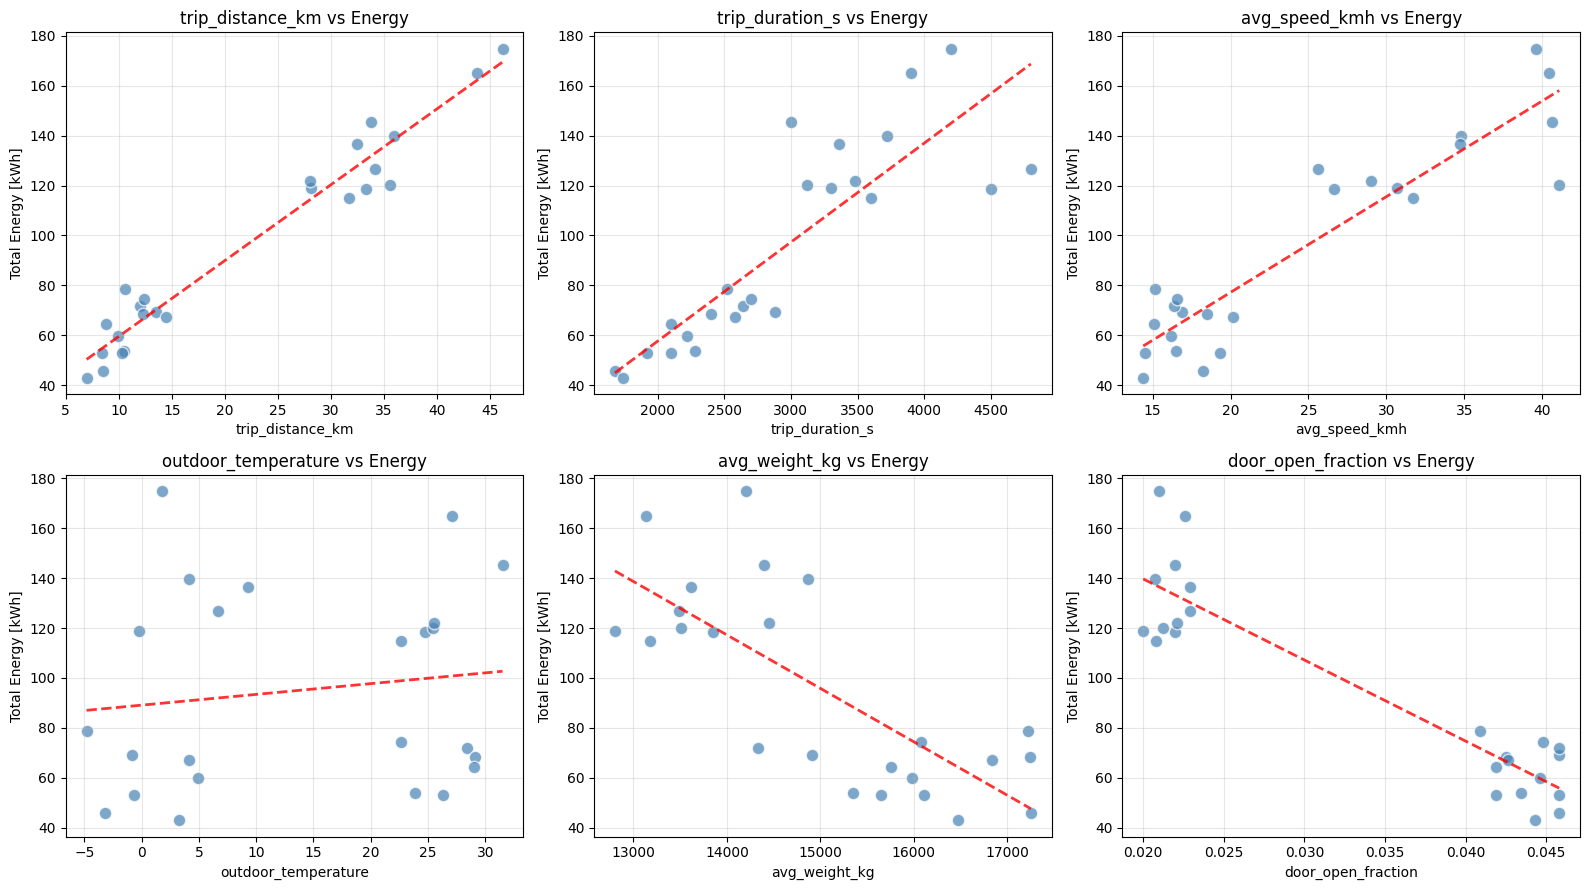

In [23]:
top_features = ['trip_distance_km', 'trip_duration_s', 'avg_speed_kmh',
                'outdoor_temperature', 'avg_weight_kg', 'door_open_fraction']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    ax.scatter(training_df[feat], training_df['total_energy_kwh'],
               alpha=0.7, edgecolors='white', s=80, color='steelblue')
    mask = training_df[[feat, 'total_energy_kwh']].notna().all(axis=1)
    if mask.sum() > 2:
        z = np.polyfit(training_df.loc[mask, feat], training_df.loc[mask, 'total_energy_kwh'], 1)
        p = np.poly1d(z)
        xs = np.linspace(training_df[feat].min(), training_df[feat].max(), 100)
        ax.plot(xs, p(xs), 'r--', alpha=0.8, lw=2)
    ax.set_xlabel(feat)
    ax.set_ylabel('Total Energy [kWh]')
    ax.set_title(f'{feat} vs Energy')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'feature_scatter_plots.png'), dpi=100)
plt.show()


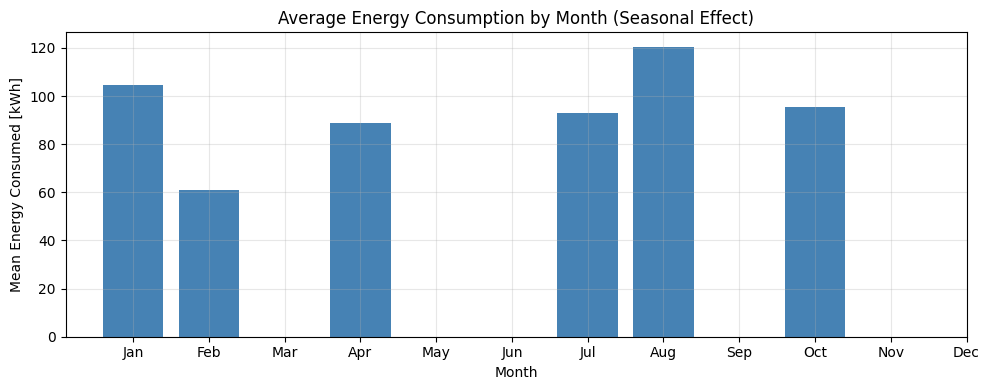

In [24]:
monthly = training_df.groupby('month')['total_energy_kwh'].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly.index, monthly.values, color='steelblue')
ax.set_xlabel('Month')
ax.set_ylabel('Mean Energy Consumed [kWh]')
ax.set_title('Average Energy Consumption by Month (Seasonal Effect)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'energy_by_month.png'), dpi=100)
plt.show()


## 10. Summary

### Processing steps

| Step | Action |
|---|---|
| **Loading** | Read 24 trip CSV files (1 Hz signal) plus hourly weather data |
| **Type cleaning** | Coerced numeric columns; `'error'` entries in `charge`/`doors` → `NaN` |
| **Missing data** | Forward/backward-fill for `charge` and `doors`; linear interpolation (≤ 30 s) for `power`, `odometer`, `temperature` |
| **Weight denoising** | Median filter → stationary-only readings → rolling-window median |
| **Energy calculation** | Integrated discharge power at 1 Hz: $E = \sum |P_i| / 3600$ |
| **Weather merge** | Joined hourly weather on rounded trip start-hour |
| **Feature engineering** | 20 features covering dynamics, stops, doors, climate, passenger load, and calendar |
| **Export** | Saved `data/training_dataset.csv` — one row per trip |

### Resulting feature set

The final dataset (`data/training_dataset.csv`) contains **24 rows × 22 columns** (20 features + `trip_id` + `total_energy_kwh` target).

### Next steps (ML model)
- Normalise/scale numeric features
- Split into train/test (leave-one-season-out or random 80/20)
- Baseline: Ridge Regression or Gradient Boosting Regressor
- Evaluation metric: MAE / RMSE in kWh
- Potential improvements: time-of-day embeddings, route segmentation, regenerative braking energy recovery
